In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

print("✅ Tất cả thư viện đã sẵn sàng!")

✅ Tất cả thư viện đã sẵn sàng!


In [2]:
# BƯỚC 1: ĐỌC VÀ LÀM SẠCH DỮ LIỆU CHUẨN HỌC THUẬT
# ==============================================================================
print("⏳ Đang nạp và tiền xử lý dữ liệu...")
file_path = r'C:\Users\My PC\Churn_Project\data\online_retail_II.csv'

# Nếu chạy local, linh hoạt đường dẫn tương đối hoặc tuyệt đối
if not os.path.exists(file_path):
    file_path = 'online_retail_II.csv'

df_raw = pd.read_csv(file_path, encoding='ISO-8859-1')
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])

if 'CustomerID' in df_raw.columns:
    df_raw = df_raw.rename(columns={'CustomerID': 'Customer ID'})

df_raw['is_cancelled'] = df_raw['Invoice'].astype(str).str.startswith('C')

# Danh mục các mã phi sản phẩm / chi phí vận hành sàn
NON_PRODUCT_CODES = {
    'POST', 'D', 'M', 'BANK CHARGES', 'DOT',
    'ADJUST', 'ADJUST2', 'CRUK', 'TEST',
    'TEST001', 'TEST002', 'C2', 'PADS', '23444',
    'AMAZONFEE', 'B', 'S', 'GIFT'
}

def lam_sach_du_lieu_giao_dich(df_input):
    """
    Làm sạch tập giao dịch mua hàng chuẩn (df_clean).
    Đảm bảo 100% đơn mua là sản phẩm thương mại thật, có Customer ID và giá dương.
    """
    df = df_input.copy()
    df = df.dropna(subset=['Customer ID'])
    df['Customer ID'] = df['Customer ID'].astype(int)
    df['Invoice'] = df['Invoice'].astype(str).str.strip()
    df['StockCode'] = df['StockCode'].astype(str).str.strip().str.upper()
    
    # Loại bỏ mã phi sản phẩm và đơn hủy
    df = df[~df['StockCode'].isin(NON_PRODUCT_CODES)]
    df = df[~df['Invoice'].str.startswith('C')]
    df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
    df = df.drop_duplicates()
    
    # Tính doanh thu thực tế
    df['Revenue'] = df['Quantity'] * df['Price']
    return df.reset_index(drop=True)

df_clean = lam_sach_du_lieu_giao_dich(df_raw)
print(f"✅ Dữ liệu thô ban đầu: {df_raw.shape}")
print(f"✅ Dữ liệu giao dịch mua sạch: {df_clean.shape} ({df_clean['Customer ID'].nunique():,} khách hàng duy nhất)")



⏳ Đang nạp và tiền xử lý dữ liệu...
✅ Dữ liệu thô ban đầu: (1067371, 9)
✅ Dữ liệu giao dịch mua sạch: (776500, 10) (5,852 khách hàng duy nhất)


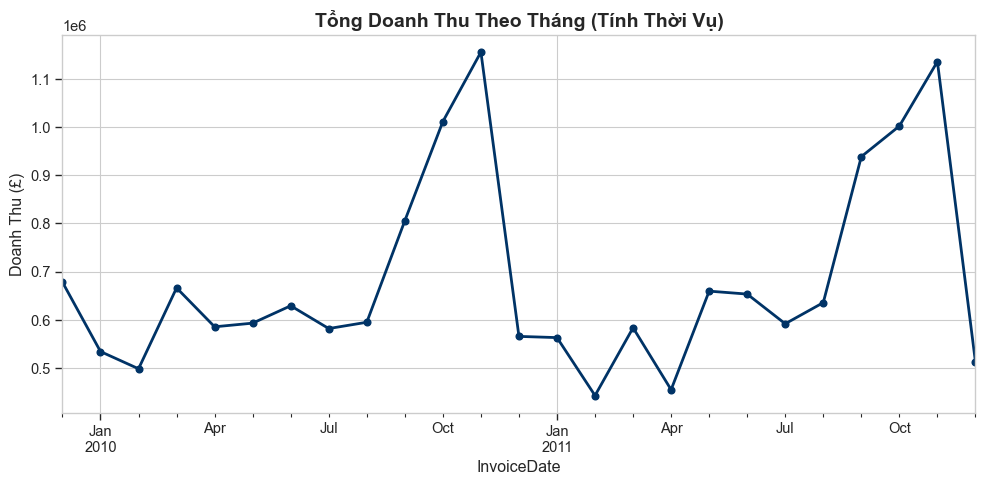

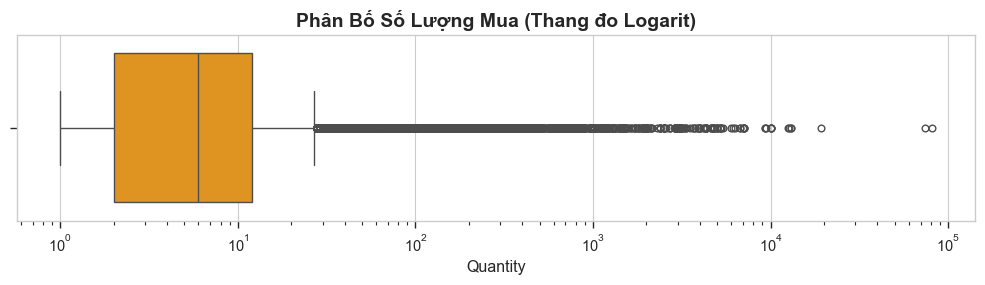

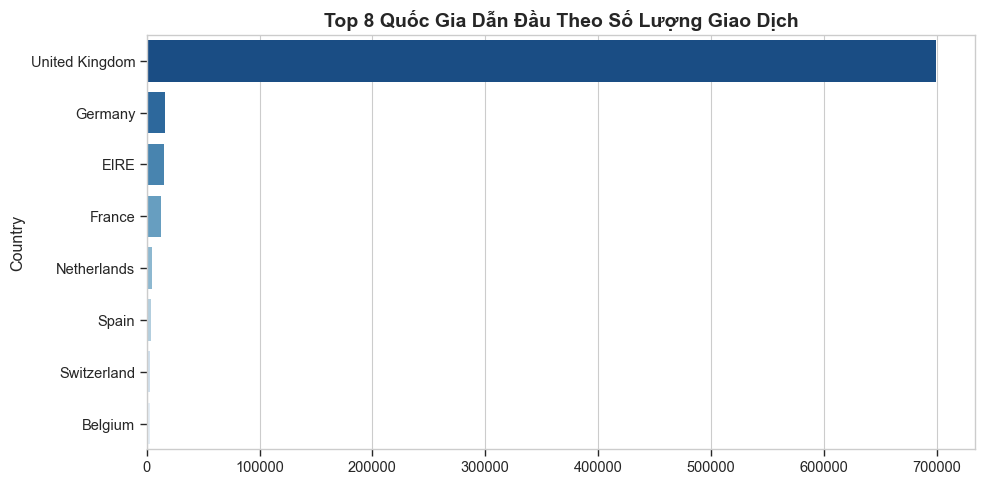

✅ Đã lưu ảnh thành công vào thư mục: docs


In [3]:
docs_dir = '../docs' if os.path.exists('../docs') else 'docs'
os.makedirs(docs_dir, exist_ok=True)

# 1. Tính thời vụ
plt.figure(figsize=(10, 5))
monthly_revenue = df_clean.set_index('InvoiceDate').resample('ME')['Revenue'].sum()
monthly_revenue.plot(kind='line', marker='o', color='#003366', linewidth=2)
plt.title('Tổng Doanh Thu Theo Tháng (Tính Thời Vụ)', fontsize=14, fontweight='bold')
plt.ylabel('Doanh Thu (£)')
plt.tight_layout()
plt.savefig(os.path.join(docs_dir, 'Bieu_Do_1_Thoi_Vu.png'), dpi=300)
plt.show()

# 2. Phân bố Số lượng (Thang đo Logarit)
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_clean['Quantity'], color='#ff9900')
plt.xscale('log') 
plt.title('Phân Bố Số Lượng Mua (Thang đo Logarit)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(docs_dir, 'Bieu_Do_2_Khach_Si_Le.png'), dpi=300)
plt.show()

# 3. Top Quốc gia
plt.figure(figsize=(10, 5))
top_countries = df_clean['Country'].value_counts().head(8)
sns.barplot(y=top_countries.index, x=top_countries.values, palette='Blues_r', hue=top_countries.index, legend=False)
plt.title('Top 8 Quốc Gia Dẫn Đầu Theo Số Lượng Giao Dịch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(docs_dir, 'Bieu_Do_3_Quoc_Gia.png'), dpi=300)
plt.show()

print(f"✅ Đã lưu ảnh thành công vào thư mục: {docs_dir}")

In [4]:
import pandas as pd
import numpy as np

def tinh_rfm_va_tenure(df_clean_input, cutoff_date):
    obs = df_clean_input[df_clean_input['InvoiceDate'] < cutoff_date]
    rfm = obs.groupby('Customer ID').agg(
        Recency=('InvoiceDate', lambda x: (cutoff_date - x.max()).days),
        Frequency=('Invoice', 'nunique'),
        Monetary=('Revenue', 'sum'),
        AvgOrderValue=('Revenue', 'mean'),
        NumProducts=('StockCode', 'nunique'),
        FirstPurchase=('InvoiceDate', 'min'),
        Country=('Country', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
    ).reset_index()
    
    rfm['Tenure'] = (cutoff_date - rfm['FirstPurchase']).dt.days
    return rfm

def them_nhip_do_mua_sam(rfm_df, obs_df):
    def std_khoang_cach(dates):
        d = np.sort(dates.unique()) 
        if len(d) < 3: return np.nan
        return float(np.std(np.diff(d) / np.timedelta64(1, 'D')))
        
    def avg_khoang_cach(dates):
        d = np.sort(dates.unique()) 
        if len(d) < 2: return np.nan
        return float(np.mean(np.diff(d) / np.timedelta64(1, 'D')))
    
    interval_std = obs_df.groupby('Customer ID')['InvoiceDate'].apply(std_khoang_cach).rename('IntervalStd').reset_index()
    interval_avg = obs_df.groupby('Customer ID')['InvoiceDate'].apply(avg_khoang_cach).rename('AvgInterval').reset_index()
    
    out = rfm_df.merge(interval_std, on='Customer ID', how='left').merge(interval_avg, on='Customer ID', how='left')
    
    # --- ĐÃ SỬA: Điền khuyết cho khách mua 1 lần ---
    # Khách mua 1 lần: Khoảng cách giữa các lần mua coi như bằng chính thời gian họ đã gắn bó (Tenure)
    out['AvgInterval'] = out['AvgInterval'].fillna(out['Tenure'])
    # Không có chu kỳ lặp lại nên độ lệch chuẩn khoảng cách = 0
    out['IntervalStd'] = out['IntervalStd'].fillna(0)
    return out

def them_xu_huong(rfm_df, obs_df, cutoff_date):
    mid_point = cutoff_date - pd.Timedelta(days=90)
    far_point = cutoff_date - pd.Timedelta(days=180)
    
    rev_recent = obs_df[obs_df['InvoiceDate'] >= mid_point].groupby('Customer ID')['Revenue'].sum()
    rev_prev = obs_df[(obs_df['InvoiceDate'] >= far_point) & (obs_df['InvoiceDate'] < mid_point)].groupby('Customer ID')['Revenue'].sum()
    freq_recent = obs_df[obs_df['InvoiceDate'] >= mid_point].groupby('Customer ID')['Invoice'].nunique()
    freq_prev = obs_df[(obs_df['InvoiceDate'] >= far_point) & (obs_df['InvoiceDate'] < mid_point)].groupby('Customer ID')['Invoice'].nunique()
    
    trend = pd.concat([rev_recent.rename('rev_recent'), rev_prev.rename('rev_prev'),
                       freq_recent.rename('freq_recent'), freq_prev.rename('freq_prev')], axis=1).fillna(0)
    trend['SpendingTrend'] = trend['rev_recent'] - trend['rev_prev']
    trend['FrequencyTrend'] = trend['freq_recent'] - trend['freq_prev']
    trend = trend[['SpendingTrend', 'FrequencyTrend']].reset_index()
    
    out = rfm_df.merge(trend, on='Customer ID', how='left')
    out[['SpendingTrend', 'FrequencyTrend']] = out[['SpendingTrend', 'FrequencyTrend']].fillna(0)
    
    # --- ĐÃ SỬA: Chặn lỗi ảo xu hướng cho khách hàng mới ---
    # Nếu thâm niên (Tenure) < 90 ngày, họ chưa có dữ liệu 90 ngày trước đó để so sánh.
    # Ta ép xu hướng về 0 để mô hình không hiểu nhầm là họ đang tăng trưởng đột biến.
    out.loc[out['Tenure'] < 90, ['SpendingTrend', 'FrequencyTrend']] = 0
    
    return out

def them_cancel_rate(rfm_df, df_raw_input, cutoff_date):
    obs_raw = df_raw_input[df_raw_input['InvoiceDate'] < cutoff_date]
    total = obs_raw.groupby('Customer ID')['Invoice'].nunique().rename('TotalInvoices')
    cancelled = obs_raw[obs_raw['is_cancelled']].groupby('Customer ID')['Invoice'].nunique().rename('CancelledInvoices')
    
    c = pd.concat([total, cancelled], axis=1).fillna(0)
    c['CancelRate'] = c['CancelledInvoices'] / c['TotalInvoices'].replace(0, np.nan)
    c = c[['CancelRate']].fillna(0).reset_index()
    out = rfm_df.merge(c, on='Customer ID', how='left')
    out['CancelRate'] = out['CancelRate'].fillna(0)
    return out

def them_repeat_purchase_ratio(rfm_df, obs_df, cutoff_date):
    tenure_months = ((cutoff_date - rfm_df['FirstPurchase']).dt.days / 30.44).clip(lower=1)
    active_months = obs_df.assign(ym=obs_df['InvoiceDate'].dt.to_period('M')).groupby('Customer ID')['ym'].nunique().rename('ActiveMonths')
    out = rfm_df.merge(active_months, on='Customer ID', how='left')
    out['ActiveMonths'] = out['ActiveMonths'].fillna(1)
    out['RepeatPurchaseRatio'] = (out['ActiveMonths'] / tenure_months).clip(upper=1.0)
    return out

def tinh_dac_trung_nang_cao(df_raw_input, df_clean_input, cutoff_date):
    obs_clean = df_clean_input[df_clean_input['InvoiceDate'] < cutoff_date].copy()
    
    features = tinh_rfm_va_tenure(df_clean_input, cutoff_date)
    features = them_nhip_do_mua_sam(features, obs_clean)
    features = them_xu_huong(features, obs_clean, cutoff_date)
    features = them_cancel_rate(features, df_raw_input, cutoff_date)
    features = them_repeat_purchase_ratio(features, obs_clean, cutoff_date)
    
    features['Is_UK'] = (features['Country'] == 'United Kingdom').astype(int)
    
    # --- ĐÃ SỬA: Chuẩn hóa Outlier cho thuật toán (Logistic Regression) ---
    # Ép giá trị tiền tệ khổng lồ (vd: 168,000) về thang Logarit (vd: 12.0)
    # clip(lower=0) để phòng trường hợp khách có doanh thu ròng âm (đổi trả nhiều hơn mua)
    features['Monetary_Log'] = np.log1p(features['Monetary'].clip(lower=0))
    features['AvgOrderValue_Log'] = np.log1p(features['AvgOrderValue'].clip(lower=0))
    
    return features.drop(columns=['FirstPurchase', 'Country'])

print("✅ Đã cập nhật xong bộ Feature Engineering chuẩn xác cho ML!")

✅ Đã cập nhật xong bộ Feature Engineering chuẩn xác cho ML!


In [5]:
max_date = df_clean['InvoiceDate'].max()

def kiem_tra_va_gan_nhan(df_clean_input, cutoff_date, churn_window_days, max_date_input):
    required_end = cutoff_date + pd.Timedelta(days=churn_window_days)
    if required_end > max_date_input: return None, False
    
    obs = df_clean_input[df_clean_input['InvoiceDate'] < cutoff_date]
    future = df_clean_input[(df_clean_input['InvoiceDate'] >= cutoff_date) & (df_clean_input['InvoiceDate'] < required_end)]
    customers_before = obs['Customer ID'].unique()
    if len(customers_before) == 0: return None, False
    
    active_future = set(future['Customer ID'].unique())
    labels = pd.Series([0 if cid in active_future else 1 for cid in customers_before], index=customers_before, name='churn')
    return labels, True

def tao_cac_fold(window_months, test_cutoffs):
    return [(t - pd.DateOffset(months=2 * window_months),
             t - pd.DateOffset(months=window_months), t) for t in test_cutoffs]

# Tạo 8 mốc thời gian cách nhau 1 tháng (cửa sổ 3 tháng)
test_cutoffs_3m = [pd.Timestamp('2011-02-01') + pd.DateOffset(months=i) for i in range(8)]
folds_3m = tao_cac_fold(3, test_cutoffs_3m)

print("✅ Danh sách 8 fold thời gian chuẩn (Train - Val - Test):")
for tr, va, te in folds_3m:
    print(f"Train={tr.date()} | Val={va.date()} | Test={te.date()}")

✅ Danh sách 8 fold thời gian chuẩn (Train - Val - Test):
Train=2010-08-01 | Val=2010-11-01 | Test=2011-02-01
Train=2010-09-01 | Val=2010-12-01 | Test=2011-03-01
Train=2010-10-01 | Val=2011-01-01 | Test=2011-04-01
Train=2010-11-01 | Val=2011-02-01 | Test=2011-05-01
Train=2010-12-01 | Val=2011-03-01 | Test=2011-06-01
Train=2011-01-01 | Val=2011-04-01 | Test=2011-07-01
Train=2011-02-01 | Val=2011-05-01 | Test=2011-08-01
Train=2011-03-01 | Val=2011-06-01 | Test=2011-09-01


In [8]:
import numpy as np
import pandas as pd
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CƠ CHẾ CACHE DỮ LIỆU ĐỂ TRÁNH TÍNH LẶP LẠI (TĂNG TỐC ĐỘ X30 LẦN)
# ==============================================================================
_data_cache = {}

def lay_du_lieu_cutoff(cutoff, window_days=90):
    cache_key = (cutoff, window_days)
    if cache_key in _data_cache:
        return _data_cache[cache_key]

    feats = tinh_dac_trung_nang_cao(df_raw, df_clean, cutoff)
    labels, is_valid = kiem_tra_va_gan_nhan(df_clean, cutoff, window_days, max_date)
    
    if not is_valid: return None
    
    merged_df = feats.merge(labels.rename('churn'), left_on='Customer ID', right_index=True)
    _data_cache[cache_key] = merged_df
    return merged_df

# ==============================================================================
# 2. XÁC ĐỊNH BỘ ĐẶC TRƯNG CHUẨN (LOẠI BỎ ĐA CỘNG TUYẾN)
# ==============================================================================
sample_df = lay_du_lieu_cutoff(pd.Timestamp('2010-08-01'), 90)

# Chú ý: Bỏ Monetary và AvgOrderValue gốc để tránh đa cộng tuyến với bản Log
cols_loai_bo = {'Customer ID', 'churn', 'Monetary', 'AvgOrderValue'}
feature_cols = [c for c in sample_df.columns if c not in cols_loai_bo]

print(f"✅ Đã chốt {len(feature_cols)} đặc trưng đưa vào mô hình.")

# ==============================================================================
# 3. HÀM TÌM NGƯỠNG TỐI ƯU F1 TRÊN TẬP VALIDATION
# ==============================================================================
def tim_nguong_f1_toi_uu(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0: return 0.5
    f1_scores = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-9, None)
    return float(thresholds[int(np.argmax(f1_scores))])

# ==============================================================================
# 4. CẤU HÌNH 4 MÔ HÌNH VỚI TRỌNG SỐ CÂN BẰNG ĐỘNG (SCALE_POS_WEIGHT)
# ==============================================================================
model_configs = {
    'LogisticRegression': {
        'builder': lambda p, seed, spw: LogisticRegression(
            random_state=seed, class_weight='balanced', max_iter=1000, **p),
        # Mở rộng dải tìm kiếm từ phạt L2 rất mạnh (0.01) đến yếu (10.0)
        'param_grid': [{'C': 0.01}, {'C': 0.1}, {'C': 1.0}, {'C': 10.0}],
        'needs_scaling': True, 'seeds': (0,)
    },
    'RandomForest': {
        'builder': lambda p, seed, spw: RandomForestClassifier(
            random_state=seed, class_weight='balanced', n_jobs=-1, **p),
        # Cấp cho RF độ sâu tương đương sức mạnh của Boosting và thử nghiệm max_features
        'param_grid': [
            {'n_estimators': 300, 'max_depth': 6, 'min_samples_leaf': 4, 'max_features': 'sqrt'},
            {'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 2, 'max_features': 'log2'},
            {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
        ],
        'needs_scaling': False, 'seeds': (0, 1, 2)
    },
    'XGBoost': {
        'builder': lambda p, seed, spw: xgb.XGBClassifier(
            random_state=seed, eval_metric='logloss', scale_pos_weight=spw, **p),
        # XGBoost giữ nguyên 3 cấu hình tối ưu mạnh nhất
        'param_grid': [
            {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
            {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3},
            {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 1.0}
        ],
        'needs_scaling': False, 'seeds': (0,)
    },
    'LightGBM': {
        'builder': lambda p, seed, spw: lgb.LGBMClassifier(
            random_state=seed, verbose=-1, scale_pos_weight=spw, **p),
        # LightGBM được trang bị vũ khí y hệt XGBoost để cạnh tranh công bằng
        'param_grid': [
            {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'num_leaves': 15},
            {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 20, 'num_leaves': 31},
            {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_samples': 30, 'num_leaves': 63}
        ],
        'needs_scaling': False, 'seeds': (0,)
    }
}

# ==============================================================================
# 5. HÀM CHẠY 1 FOLD HOÀN CHỈNH
# ==============================================================================
def thuc_thi_1_fold(model_name, feature_cols, train_df, val_df, test_df):
    cfg = model_configs[model_name]
    
    Xtr, ytr = train_df[feature_cols].copy(), train_df['churn'].values
    Xva, yva = val_df[feature_cols].copy(), val_df['churn'].values
    Xte, yte = test_df[feature_cols].copy(), test_df['churn'].values

    if cfg['needs_scaling']:
        scaler = StandardScaler().fit(Xtr)
        Xtr, Xva, Xte = scaler.transform(Xtr), scaler.transform(Xva), scaler.transform(Xte)

    # Tính trọng số phạt tự động cho các mô hình Tree-Boosting
    num_neg = np.sum(ytr == 0)
    num_pos = np.sum(ytr == 1)
    spw = float(num_neg / np.clip(num_pos, 1, None))

    seed_roc, seed_pr, seed_prec, seed_rec, seed_f1 = [], [], [], [], []
    seed_cm = np.zeros((2, 2), dtype=int)

    for seed in cfg['seeds']:
        # Tìm bộ tham số có AUC cao nhất trên tập Validation
        best_auc, best_p = -1.0, cfg['param_grid'][0]
        for params in cfg['param_grid']:
            clf = cfg['builder'](params, seed, spw).fit(Xtr, ytr)
            v_auc = roc_auc_score(yva, clf.predict_proba(Xva)[:, 1])
            if v_auc > best_auc: best_auc, best_p = v_auc, params

        # Huấn luyện mô hình chuẩn và đánh giá trên Test
        final_clf = cfg['builder'](best_p, seed, spw).fit(Xtr, ytr)
        val_probs = final_clf.predict_proba(Xva)[:, 1]
        test_probs = final_clf.predict_proba(Xte)[:, 1]

        nguong = tim_nguong_f1_toi_uu(yva, val_probs)
        y_pred = (test_probs >= nguong).astype(int)

        seed_roc.append(roc_auc_score(yte, test_probs))
        seed_pr.append(average_precision_score(yte, test_probs))
        seed_prec.append(precision_score(yte, y_pred, zero_division=0))
        seed_rec.append(recall_score(yte, y_pred, zero_division=0))
        seed_f1.append(f1_score(yte, y_pred, zero_division=0))
        seed_cm += confusion_matrix(yte, y_pred, labels=[0, 1])

    # Trả về trung bình các chỉ số qua các seed (ma trận nhầm lẫn làm tròn)
    so_seed = len(cfg['seeds'])
    return {
        'roc_auc': np.mean(seed_roc), 'pr_auc': np.mean(seed_pr),
        'precision': np.mean(seed_prec), 'recall': np.mean(seed_rec),
        'f1': np.mean(seed_f1), 'cm': np.round(seed_cm / so_seed).astype(int)
    }

# ==============================================================================
# 6. THỰC THI 8 FOLD VÀ XUẤT KẾT QUẢ TỔNG HỢP
# ==============================================================================
print("\n📦 Đang tiền xử lý toàn bộ 8 fold...")
folds_data = []
for tr_c, va_c, te_c in folds_3m:
    folds_data.append((lay_du_lieu_cutoff(tr_c), lay_du_lieu_cutoff(va_c), lay_du_lieu_cutoff(te_c)))

print("\n🚀 Bắt đầu huấn luyện...")
ket_qua = {}
for name in model_configs:
    print(f"   -> Đang chạy {name}...")
    ket_qua[name] = [thuc_thi_1_fold(name, feature_cols, tr, va, te) for tr, va, te in folds_data]

# Tổng hợp bảng Pandas báo cáo
bang_tong_hop = []
for name, folds in ket_qua.items():
    roc = [f['roc_auc'] for f in folds]
    pr = [f['pr_auc'] for f in folds]
    f1 = [f['f1'] for f in folds]
    tong_cm = np.sum([f['cm'] for f in folds], axis=0)

    bang_tong_hop.append({
        'Mô hình': name,
        'ROC-AUC': f"{np.mean(roc):.3f} ± {np.std(roc, ddof=1):.3f}",
        'PR-AUC': f"{np.mean(pr):.3f} ± {np.std(pr, ddof=1):.3f}",
        'F1-Score': f"{np.mean(f1):.3f} ± {np.std(f1, ddof=1):.3f}",
        'TN (Tổng)': tong_cm[0, 0], 'FP (Sai)': tong_cm[0, 1],
        'FN (Bỏ lọt)': tong_cm[1, 0], 'TP (Đúng)': tong_cm[1, 1]
    })

df_ket_qua = pd.DataFrame(bang_tong_hop).set_index('Mô hình')
print("\n🏆 KẾT QUẢ TỔNG HỢP SAU 8 FOLD:")
display(df_ket_qua)

✅ Đã chốt 14 đặc trưng đưa vào mô hình.

📦 Đang tiền xử lý toàn bộ 8 fold...

🚀 Bắt đầu huấn luyện...
   -> Đang chạy LogisticRegression...
   -> Đang chạy RandomForest...
   -> Đang chạy XGBoost...
   -> Đang chạy LightGBM...

🏆 KẾT QUẢ TỔNG HỢP SAU 8 FOLD:


,ROC-AUC,PR-AUC,F1-Score,TN (Tổng),FP (Sai),FN (Bỏ lọt),TP (Đúng)
Mô hình,,,,,,,
LogisticRegression,0.793 ± 0.012,0.854 ± 0.019,0.822 ± 0.017,6438,7452,2280,22482
RandomForest,0.796 ± 0.015,0.853 ± 0.021,0.828 ± 0.018,5502,8388,1328,23434
XGBoost,0.789 ± 0.016,0.847 ± 0.022,0.827 ± 0.018,5408,8482,1334,23428
LightGBM,0.786 ± 0.015,0.845 ± 0.022,0.826 ± 0.018,5124,8766,1189,23573


In [9]:
import itertools
from scipy.stats import wilcoxon

# ==============================================================================
# 8. KIỂM ĐỊNH WILCOXON: SO SÁNH Ý NGHĨA THỐNG KÊ GIỮA CÁC MÔ HÌNH
# ==============================================================================
print("⚖️ KIỂM ĐỊNH WILCOXON GIỮA CÁC MÔ HÌNH (Trên 8 Fold Độc lập):")
# Lấy chuỗi 8 giá trị ROC-AUC của từng mô hình từ biến ket_qua đã chạy trước đó
pivot_roc = {name: [f['roc_auc'] for f in folds] for name, folds in ket_qua.items()}

for m1, m2 in itertools.combinations(model_configs.keys(), 2):
    stat_roc, p_roc = wilcoxon(pivot_roc[m1], pivot_roc[m2])
    # Đếm số fold m1 có ROC-AUC cao hơn m2
    thang = sum(a > b for a, b in zip(pivot_roc[m1], pivot_roc[m2]))
    print(f"   -> {m1:18s} vs {m2:18s}: p-value = {p_roc:.4f} | {m1} thắng {thang}/8 fold")

# ==============================================================================
# 9. ABLATION STUDY: ĐÁNH GIÁ SỨC MẠNH CỦA NHÓM ĐẶC TRƯNG THỜI GIAN
# ==============================================================================
print("\n🔪 ABLATION STUDY: GIÁ TRỊ CỦA FEATURE ENGINEERING (Chuỗi thời gian)")

# Khai báo nhóm biến hành vi theo thời gian bạn đã thiết lập
temporal_extra = ['IntervalStd', 'SpendingTrend', 'FrequencyTrend', 'RepeatPurchaseRatio']

# Tự động tạo bộ biến cơ bản bằng cách loại trừ các biến thời gian khỏi bộ chuẩn
basic_cols = [c for c in feature_cols if c not in temporal_extra]
print(f"   * Số lượng đặc trưng tĩnh (Basic): {len(basic_cols)} biến")
print(f"   * Số lượng đặc trưng bổ sung (Temporal): {len(temporal_extra)} biến")

# Chỉ huấn luyện duy nhất mô hình Random Forest trên bộ Basic
# (Vì bộ Temporal/Full đã được chạy sẵn và lưu trong ket_qua['RandomForest'])
print("   -> Đang huấn luyện lại RandomForest trên bộ đặc trưng Basic...")
ket_qua_basic = [
    thuc_thi_1_fold('RandomForest', basic_cols, tr_df, va_df, te_df) 
    for tr_df, va_df, te_df in folds_data
]

# Trích xuất ROC-AUC để so sánh
roc_basic = [f['roc_auc'] for f in ket_qua_basic]
roc_full = pivot_roc['RandomForest'] # Lấy trực tiếp từ lần chạy trước

# Kiểm định Wilcoxon giữa bộ thiếu biến và bộ đủ biến
stat, p = wilcoxon(roc_basic, roc_full)
so_fold_thang = sum(b > a for a, b in zip(roc_basic, roc_full))

print("\n🏆 KẾT QUẢ ABLATION STUDY:")
print(f"   👉 RFM tĩnh cơ bản       : ROC-AUC = {np.mean(roc_basic):.4f}")
print(f"   👉 RFM + Thời gian       : ROC-AUC = {np.mean(roc_full):.4f}")
print(f"   📌 P-value = {p:.4f} (Mô hình có biến thời gian thắng {so_fold_thang}/8 fold)")

⚖️ KIỂM ĐỊNH WILCOXON GIỮA CÁC MÔ HÌNH (Trên 8 Fold Độc lập):
   -> LogisticRegression vs RandomForest      : p-value = 0.0391 | LogisticRegression thắng 1/8 fold
   -> LogisticRegression vs XGBoost           : p-value = 0.0547 | LogisticRegression thắng 6/8 fold
   -> LogisticRegression vs LightGBM          : p-value = 0.0078 | LogisticRegression thắng 8/8 fold
   -> RandomForest       vs XGBoost           : p-value = 0.0078 | RandomForest thắng 8/8 fold
   -> RandomForest       vs LightGBM          : p-value = 0.0078 | RandomForest thắng 8/8 fold
   -> XGBoost            vs LightGBM          : p-value = 0.0078 | XGBoost thắng 8/8 fold

🔪 ABLATION STUDY: GIÁ TRỊ CỦA FEATURE ENGINEERING (Chuỗi thời gian)
   * Số lượng đặc trưng tĩnh (Basic): 10 biến
   * Số lượng đặc trưng bổ sung (Temporal): 4 biến
   -> Đang huấn luyện lại RandomForest trên bộ đặc trưng Basic...

🏆 KẾT QUẢ ABLATION STUDY:
   👉 RFM tĩnh cơ bản       : ROC-AUC = 0.7935
   👉 RFM + Thời gian       : ROC-AUC = 0.7962
   📌